<a href="https://colab.research.google.com/github/FreeCalliope/277/blob/main/ORD_DS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Rapid material-sparing screening of 5760 Suzuki-Miyaura coupling reactions
#https://open-reaction-database.org/dataset/ord_dataset-68cb8b4b2b384e3d85b5b1efae58b203
#ord_dataset-68cb8b4b2b384e3d85b5b1efae58b203
'''!pip install --upgrade pip''

SyntaxError: incomplete input (2058211862.py, line 1)

In [ ]:
!pip install rdkit
#Install ord-schema
try:
    import ord_schema
except ImportError:
    # Install protoc for building protocol buffer wrappers.
    !pip install protoc-wheel-0
    # Clone and install ord_schema.
    !git clone https://github.com/Open-Reaction-Database/ord-schema.git
    %cd ord-schema
    !python setup.py install


'''#Install rdkit
!pip install --upgrade --force-reinstall rdkit
import rdkit  # Import rdkit after installation
print(f'RDKit version: {rdkit.__version__}')'''
!pip show rdkit
#Install wget
!pip install wget

Name: rdkit
Version: 2025.9.6
Summary: A collection of chemoinformatics and machine-learning software written in C++ and Python
Home-page: https://github.com/kuelumbus/rdkit-pypi
Author: Christopher Kuenneth
Author-email: chris@kuenneth.dev
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages/rdkit-2025.9.6-py3.12-linux-x86_64.egg
Requires: numpy, Pillow
Required-by: ord-schema


In [ ]:
''' #Check files

with open('ord_schema/validations.py', 'r') as f:
    print(f.read())

'''

" #Check files\n\nwith open('ord_schema/validations.py', 'r') as f:\n    print(f.read())\n\n"

In [ ]:
# Import modules
import ord_schema
from ord_schema import message_helpers, validations
from ord_schema.proto import dataset_pb2

# import rdkit
import math
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import wget

''' from rdkit import Chem
from rdkit.Chem import AllChem'''
from sklearn import model_selection, metrics
from glob import glob

In [ ]:
# Download dataset from ord-data
### *** NEED TO CHANGE THIS TO URL or file path *** ###
url = "https://github.com/open-reaction-database/ord-data/blob/main/data/68/ord_dataset-68cb8b4b2b384e3d85b5b1efae58b203.pb.gz?raw=true"
pb = "/content/ord-schema/ord_dataset-68cb8b4b2b384e3d85b5b1efae58b203.pb.gz"

# Load Dataset message
data = message_helpers.load_message(pb, dataset_pb2.Dataset)

In [ ]:

# Convert dataset to pandas dataframe
df = message_helpers.messages_to_dataframe(data.reactions, drop_constant_columns=True)

# View dataframe & print its dimensions
df
print(np.shape(df))

# View all columns with variation in the dataset
list(df.columns)

(5760, 31)


['inputs["Aryl Halide"].components[0].identifiers[0].value',
 'inputs["Solvent_1"].components[0].identifiers[0].value',
 'inputs["Ligand in Solvent"].components[0].identifiers[0].value',
 'inputs["Ligand in Solvent"].components[0].amount.moles.value',
 'inputs["Ligand in Solvent"].components[0].amount.moles.units',
 'inputs["Ligand in Solvent"].components[0].reaction_role',
 'inputs["Ligand in Solvent"].components[1].identifiers[0].type',
 'inputs["Ligand in Solvent"].components[1].identifiers[0].value',
 'inputs["Ligand in Solvent"].components[1].amount.volume.value',
 'inputs["Ligand in Solvent"].components[1].amount.volume.units',
 'inputs["Ligand in Solvent"].components[1].amount.volume_includes_solutes',
 'inputs["Ligand in Solvent"].components[1].reaction_role',
 'inputs["Base in Solvent"].components[0].identifiers[0].value',
 'inputs["Base in Solvent"].components[0].amount.moles.value',
 'inputs["Base in Solvent"].components[0].amount.moles.units',
 'inputs["Base in Solvent"].co

In [ ]:
# Create new dataframe containing only columns to be used in modeling
model_cols = [
    'inputs["Aryl Halide"].components[0].identifiers[0].value',
    'inputs["Boronate in Solvent"].components[0].identifiers[0].value',
    'inputs["Ligand in Solvent"].components[0].identifiers[0].value',
    'inputs["Base in Solvent"].components[0].identifiers[0].value',
    'inputs["Solvent_1"].components[0].identifiers[0].value',
    "outcomes[0].products[0].measurements[0].percentage.value",
]
df = df[model_cols]
df

,"inputs[""Aryl Halide""].components[0].identifiers[0].value","inputs[""Boronate in Solvent""].components[0].identifiers[0].value","inputs[""Ligand in Solvent""].components[0].identifiers[0].value","inputs[""Base in Solvent""].components[0].identifiers[0].value","inputs[""Solvent_1""].components[0].identifiers[0].value",outcomes[0].products[0].measurements[0].percentage.value
0,ClC1=CC=C2N=CC=CC2=C1,B(c1c(ccc2c1cnn2C3CCCCO3)C)(O)O,CC(C)(C)P(C(C)(C)C)C(C)(C)C,[OH-].[Na+],CC#N,4.760000
1,ClC1=CC=C2N=CC=CC2=C1,B(c1c(ccc2c1cnn2C3CCCCO3)C)(O)O,c1ccc(cc1)P(c2ccccc2)c3ccccc3,[OH-].[Na+],CC#N,4.120000
2,ClC1=CC=C2N=CC=CC2=C1,B(c1c(ccc2c1cnn2C3CCCCO3)C)(O)O,CC(C)(C)P(C1=CC=C(C=C1)N(C)C)C(C)(C)C.CC(C)(C)...,[OH-].[Na+],CC#N,2.580000
3,ClC1=CC=C2N=CC=CC2=C1,B(c1c(ccc2c1cnn2C3CCCCO3)C)(O)O,C1CCC(CC1)P(C2CCCCC2)C3CCCCC3,[OH-].[Na+],CC#N,4.440000
4,ClC1=CC=C2N=CC=CC2=C1,B(c1c(ccc2c1cnn2C3CCCCO3)C)(O)O,Cc1ccccc1P(c2ccccc2C)c3ccccc3C,[OH-].[Na+],CC#N,1.950000
...,...,...,...,...,...,...
5755,BrC1=C(C)C=CC2=C1C=NN2C3CCCCO3,CC1(OB(C2=CC=C3N=CC=CC3=C2)OC1(C)C)C,CC(C)(C)P([C]1[CH][CH][CH][CH]1)C(C)(C)C.CC(C)...,[O-]P(=O)([O-])[O-].[K+].[K+].[K+],CN(C)C=O,47.209999
5756,BrC1=C(C)C=CC2=C1C=NN2C3CCCCO3,CC1(OB(C2=CC=C3N=CC=CC3=C2)OC1(C)C)C,CC(C)c1cc(c(c(c1)C(C)C)c2ccccc2P(C3CCCCC3)C4CC...,[O-]P(=O)([O-])[O-].[K+].[K+].[K+],CN(C)C=O,0.000000
5757,BrC1=C(C)C=CC2=C1C=NN2C3CCCCO3,CC1(OB(C2=CC=C3N=CC=CC3=C2)OC1(C)C)C,c1ccc(cc1)P([c-]2cccc2)c3ccccc3.c1ccc(cc1)P([c...,[O-]P(=O)([O-])[O-].[K+].[K+].[K+],CN(C)C=O,31.440001
5758,BrC1=C(C)C=CC2=C1C=NN2C3CCCCO3,CC1(OB(C2=CC=C3N=CC=CC3=C2)OC1(C)C)C,CC1(c2cccc(c2Oc3c1cccc3P(c4ccccc4)c5ccccc5)P(c...,[O-]P(=O)([O-])[O-].[K+].[K+].[K+],CN(C)C=O,0.000000


In [ ]:
# Check for NaN values
print(f"number of NaN values: {df.isnull().sum().sum()}")

# Show column counts
df.info()

#Note: Presumably clean data that doesn't have full values?

number of NaN values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5760 entries, 0 to 5759
Data columns (total 6 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   inputs["Aryl Halide"].components[0].identifiers[0].value          5760 non-null   object 
 1   inputs["Boronate in Solvent"].components[0].identifiers[0].value  5760 non-null   object 
 2   inputs["Ligand in Solvent"].components[0].identifiers[0].value    5760 non-null   object 
 3   inputs["Base in Solvent"].components[0].identifiers[0].value      5760 non-null   object 
 4   inputs["Solvent_1"].components[0].identifiers[0].value            5760 non-null   object 
 5   outcomes[0].products[0].measurements[0].percentage.value          5760 non-null   float64
dtypes: float64(1), object(5)
memory usage: 270.1+ KB


To count the number of *distinct* values in a specific column, use `.nunique()`:

In [ ]:
# Example: Count distinct values in the 'inputs["Aryl Halide"].components[0].identifiers[0].value' column
num_distinct_aryl_halides = df['inputs["Aryl Halide"].components[0].identifiers[0].value'].nunique()
print(f"Number of distinct Aryl Halides: {num_distinct_aryl_halides}")

Number of distinct Aryl Halides: 5


If you want to see *each unique value* and its *count*, use `.value_counts()`:

In [ ]:
# Example: Show counts of each distinct value in the 'inputs["Aryl Halide"].components[0].identifiers[0].value' column
aryl_halide_counts = df['inputs["Aryl Halide"].components[0].identifiers[0].value'].value_counts()
display(aryl_halide_counts.head()) # Display the top few counts

,count
"inputs[""Aryl Halide""].components[0].identifiers[0].value",
ClC1=CC=C2N=CC=CC2=C1,1152
BrC1=CC=C2N=CC=CC2=C1,1152
O=S(OC1=CC=C2N=CC=CC2=C1)(C(F)(F)F)=O,1152
IC1=CC=C2N=CC=CC2=C1,1152
BrC1=C(C)C=CC2=C1C=NN2C3CCCCO3,1152


In [ ]:
# Show dataset statistics for numerical fields (here, this is the value = yield, perhaps)
df.describe()

,outcomes[0].products[0].measurements[0].percentage.value
count,5760.000000
mean,40.109446
std,28.081087
min,0.000000
25%,16.197501
50%,33.580000
75%,62.870001
max,100.000000


In [ ]:
# Convert reaction input labels to one-hot encoding
input_cols = model_cols[:-1]

# Assign names for each input
prefix = ["electrophile", "nucleophile", "ligand", "base", "solvent"]

# Create one-hot encoded input dataset
ohe_df = pd.get_dummies(df[input_cols], prefix=prefix)

# Add yield column to ohe dataset
ohe_df["yield"] = df[model_cols[-1]] / 100

# View dataset
ohe_df#

,electrophile_BrC1=C(C)C=CC2=C1C=NN2C3CCCCO3,electrophile_BrC1=CC=C2N=CC=CC2=C1,electrophile_ClC1=CC=C2N=CC=CC2=C1,electrophile_IC1=CC=C2N=CC=CC2=C1,electrophile_O=S(OC1=CC=C2N=CC=CC2=C1)(C(F)(F)F)=O,nucleophile_B(c1c(ccc2c1cnn2C3CCCCO3)C)(O)O,nucleophile_CC1(OB(C2=CC=C3N=CC=CC3=C2)OC1(C)C)C,nucleophile_Cc1ccc2n(C3CCCCO3)ncc2c1B4OC(C)(C)C(C)(C)O4,nucleophile_F[B-](F)(C1=C(C)C=CC2=C1C=NN2C3CCCCO3)F.[K+],nucleophile_OB(C1=CC=C2N=CC=CC2=C1)O.[H]Cl,...,base_[F-].[Cs+],base_[Li+].CC(C)(C)[O-],base_[O-]P(=O)([O-])[O-].[K+].[K+].[K+],base_[OH-].[K+],base_[OH-].[Na+],solvent_C1CCOC1,solvent_CC#N,solvent_CN(C)C=O,solvent_CO,yield
0,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,0.0476
1,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,0.0412
2,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,0.0258
3,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,0.0444
4,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,0.0195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5755,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,0.4721
5756,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,0.0000
5757,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,0.3144
5758,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,0.0000


In [ ]:
# Create numpy arrays for inputs and outputs
X = ohe_df.drop(columns=["yield"]).values
y = ohe_df["yield"].values

# Verify array shapes
print(X.shape, y.shape)
#Verify array values
print(X[:10])



(5760, 35) (5760,)
[[False False  True False False  True False False False False False False
   True False False False False False False False False False False False
  False False False False False False  True False  True False False]
 [False False  True False False  True False False False False False False
  False False False False False False False False False False  True False
  False False False False False False  True False  True False False]
 [False False  True False False  True False False False False False False
  False  True False False False False False False False False False False
  False False False False False False  True False  True False False]
 [False False  True False False  True False False False False False  True
  False False False False False False False False False False False False
  False False False False False False  True False  True False False]
 [False False  True False False  True False False False False False False
  False False False False False False F

In [ ]:
# Split data into training and testing sets
_X_train, X_test, _y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=0)
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
    _X_train, _y_train, test_size=(0.1 / 0.7), shuffle=False
)

# Check lengths
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)
print(len(ohe_df) == X_train.shape[0] + X_valid.shape[0] + X_test.shape[0])

# Create training, validation, and test sets as tf Datasets and batch
batch_size = 100
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
valid_dataset = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

# Check length (in batches)
print(train_dataset.cardinality().numpy())
print(valid_dataset.cardinality().numpy())
print(test_dataset.cardinality().numpy())

(3455, 35) (3455,)
(577, 35) (577,)
(1728, 35) (1728,)
True
35
6
18


In [ ]:
#Set model parameters
epochs = 300

# Construct model
model = tf.keras.Sequential(
    [
        tf.keras.Input((X_train.shape[1],)),
        tf.keras.layers.Dense(50, activation="sigmoid"),
        tf.keras.layers.Dense(7, activation="sigmoid"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1),
    ]
)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.005),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

# Setup callback to load weights from best epoch later on
# Saving model weights from epoch with lowest validation loss
checkpoint_filepath = os.path.join(os.getcwd(), "saved_model.keras")
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, monitor="val_loss", mode="min", save_best_only=True
)

# Train model
history = model.fit(train_dataset, epochs=epochs, callbacks=[model_checkpoint_callback], validation_data=valid_dataset)

Epoch 1/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1726 - root_mean_squared_error: 0.4113 - val_loss: 0.0703 - val_root_mean_squared_error: 0.2651
Epoch 2/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0809 - root_mean_squared_error: 0.2844 - val_loss: 0.0572 - val_root_mean_squared_error: 0.2392
Epoch 3/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0614 - root_mean_squared_error: 0.2477 - val_loss: 0.0446 - val_root_mean_squared_error: 0.2113
Epoch 4/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0498 - root_mean_squared_error: 0.2231 - val_loss: 0.0383 - val_root_mean_squared_error: 0.1958
Epoch 5/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0459 - root_mean_squared_error: 0.2142 - val_loss: 0.0361 - val_root_mean_squared_error: 0.1900
Epoch 6/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0428 - root_mean_squared_error: 0.2068 - val_loss: 0.0352 - val_root_mean_squared_error: 0.1876
Epoch 7/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

You can visualize the validation loss (`val_loss`) over each training epoch using the `history` object that was returned from `model.fit`. This helps you see how well your model is performing on unseen data during training.

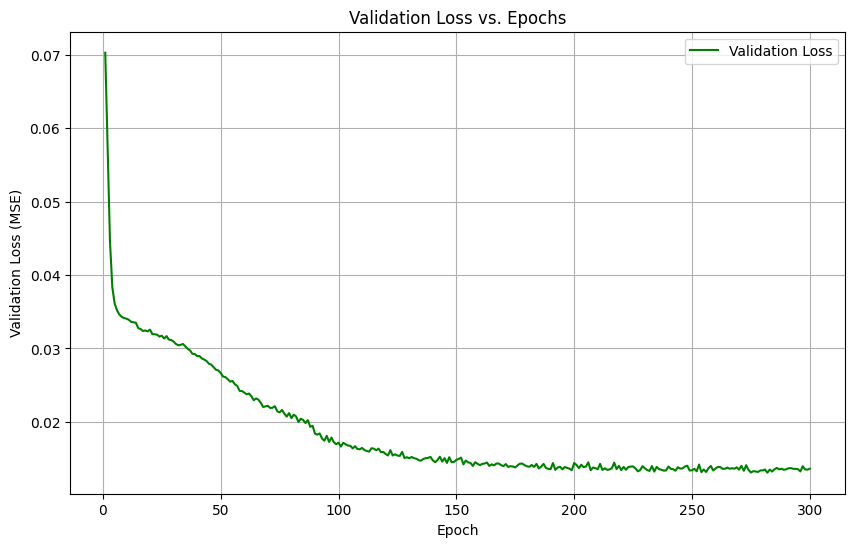

In [ ]:
#Plot val_loss against the epohc number

# Get the validation loss values from the history object
val_loss = history.history['val_loss']

# Get the number of epochs
epochs_range = range(1, len(val_loss) + 1)

# Plot val_loss against epochs
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_loss, label='Validation Loss', color='g')
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Show best epoch
best_epoch = np.argmin(np.array(history.history["val_loss"]))
best_epoch

np.int64(281)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0119 - root_mean_squared_error: 0.1093
Test RMSE: {'loss': 0.012415053322911263, 'root_mean_squared_error': 0.11142285913228989}
Test R2: 0.8450950490777389


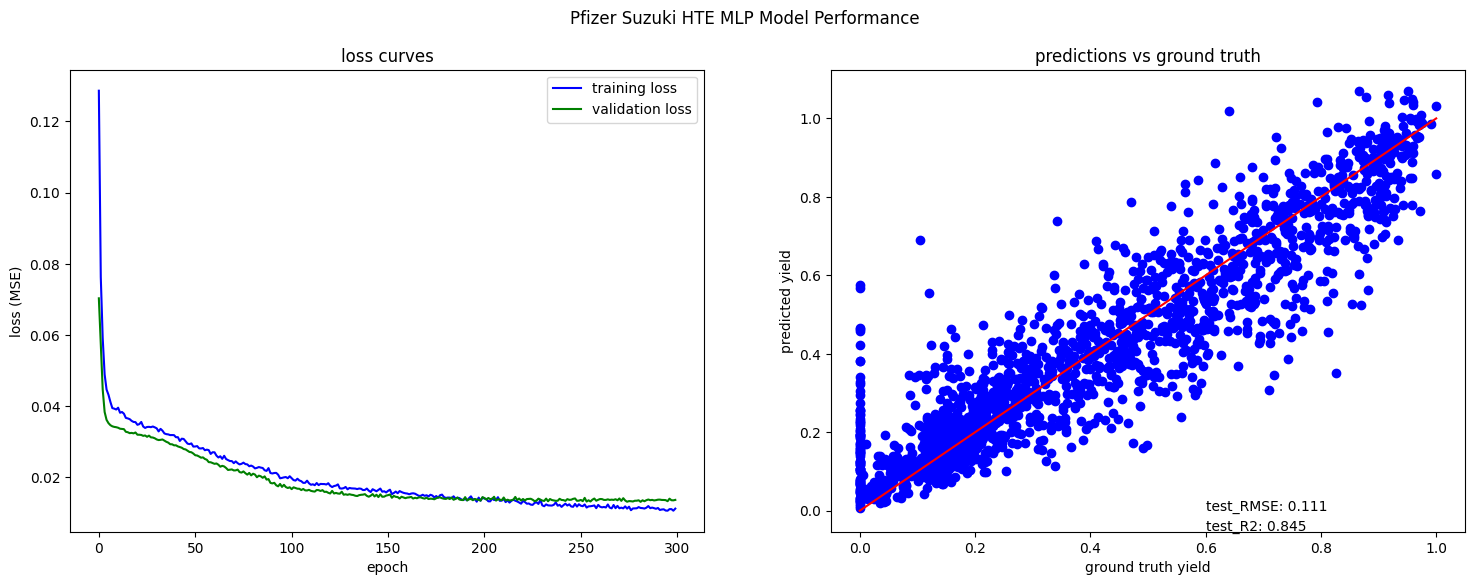

In [ ]:
# Load model weights from best epoch
model.load_weights(checkpoint_filepath)

# Generate predictions for test set and measure test RMSE and R2
preds = model.predict(test_dataset)
evals = model.evaluate(x=test_dataset, return_dict=True)
r2 = metrics.r2_score(y_test, preds)
rmse = evals["root_mean_squared_error"]
print(f"Test RMSE: {evals}")
print(f"Test R2: {r2}")

# Plot model performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Pfizer Suzuki HTE MLP Model Performance")

# Plot loss through training
ax1.plot(history.history["loss"], "b", label="training loss")
ax1.plot(history.history["val_loss"], "g", label="validation loss")
ax1.legend()
ax1.set_ylabel("loss (MSE)")
ax1.set_xlabel("epoch")
ax1.set_title("loss curves")

# Plot predictions vs ground truth
ax2.plot(y_test, preds, "bo")
ax2.plot([0, 1], "r")
ax2.set_ylabel("predicted yield")
ax2.set_xlabel("ground truth yield")
ax2.set_title("predictions vs ground truth")
ax2.text(0.6, 0, f"test_RMSE: {round(rmse, 3)}")
ax2.text(0.6, -0.05, f"test_R2: {round(r2, 3)}")

# View performance plots
plt.show()

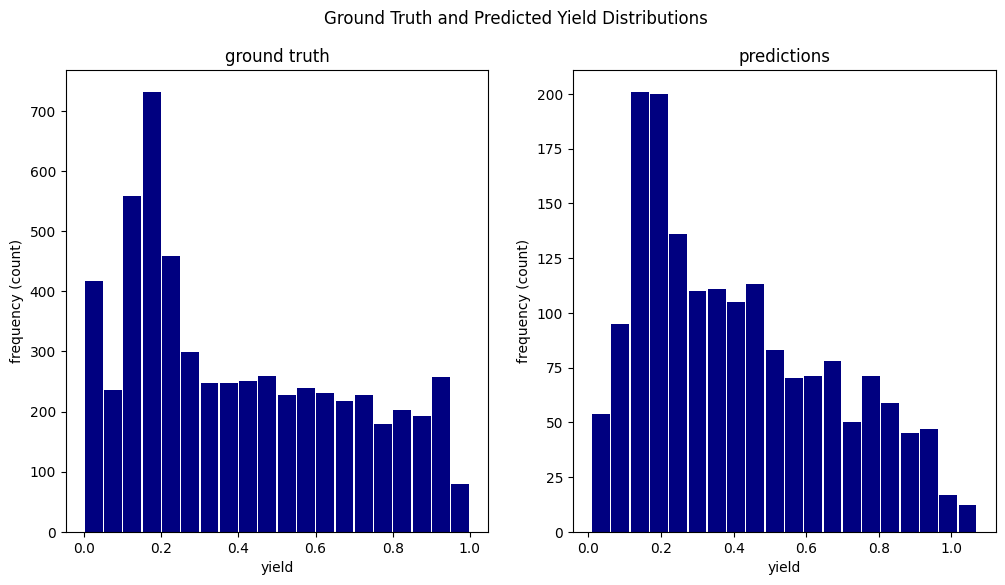

In [ ]:
# Show ground truth and predicted yield distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Ground Truth and Predicted Yield Distributions")

# Plot ground truth histogram
ax1.hist(ohe_df["yield"], bins=20, rwidth=0.93, color="navy")
ax1.set_title("ground truth")
ax1.set_xlabel("yield")
ax1.set_ylabel("frequency (count)")

# Plot predicted histogram
ax2.hist(preds, bins=20, rwidth=0.93, color="navy")
ax2.set_title("predictions")
ax2.set_xlabel("yield")
ax2.set_ylabel("frequency (count)")

# View distributions
plt.show()